In [3]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import kagglehub
import numpy as np
import pandas as pd
from collections import defaultdict, Counter
from tqdm import tqdm
import shutil
import cv2
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [4]:
# Download latest version of the data-set from kaggle
path = kagglehub.dataset_download("slavkoprytula/aquarium-data-cots")
print("Downloaded to:", path)

shutil.copytree(path, "/content/aquarium-data", dirs_exist_ok=True)
DATA_ROOT = "/content/aquarium-data/aquarium_pretrain"


Using Colab cache for faster access to the 'aquarium-data-cots' dataset.
Downloaded to: /kaggle/input/aquarium-data-cots


In [5]:

SPLIT = "train"

IMG_DIR = os.path.join(DATA_ROOT, SPLIT, "images")
LBL_DIR = os.path.join(DATA_ROOT, SPLIT, "labels")

CLASS_NAMES = ["fish", "jellyfish", "penguin", "shark", "puffin", "stingray", "starfish"]

def read_label(txt_path):
    out = []
    with open(txt_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) != 5:
                continue
            cls_id = int(float(parts[0]))
            cx, cy, w, h = map(float, parts[1:])
            out.append((cls_id, cx, cy, w, h))
    return out

def convert_coords(txt_path, img_w, img_h):
    # (cls_id, cx, cy, w, h)
    boxes = []
    labels = []

    out = read_label(txt_path)  # list of tuples
    for (cls_id, cx, cy, w, h) in out:
        x1 = (cx - w/2) * img_w
        y1 = (cy - h/2) * img_h
        x2 = (cx + w/2) * img_w
        y2 = (cy + h/2) * img_h

        boxes.append([x1, y1, x2, y2])
        labels.append(cls_id)

    return boxes, labels

image_files = [f for f in os.listdir(IMG_DIR) if f.endswith((".jpg",".png",".jpeg"))]



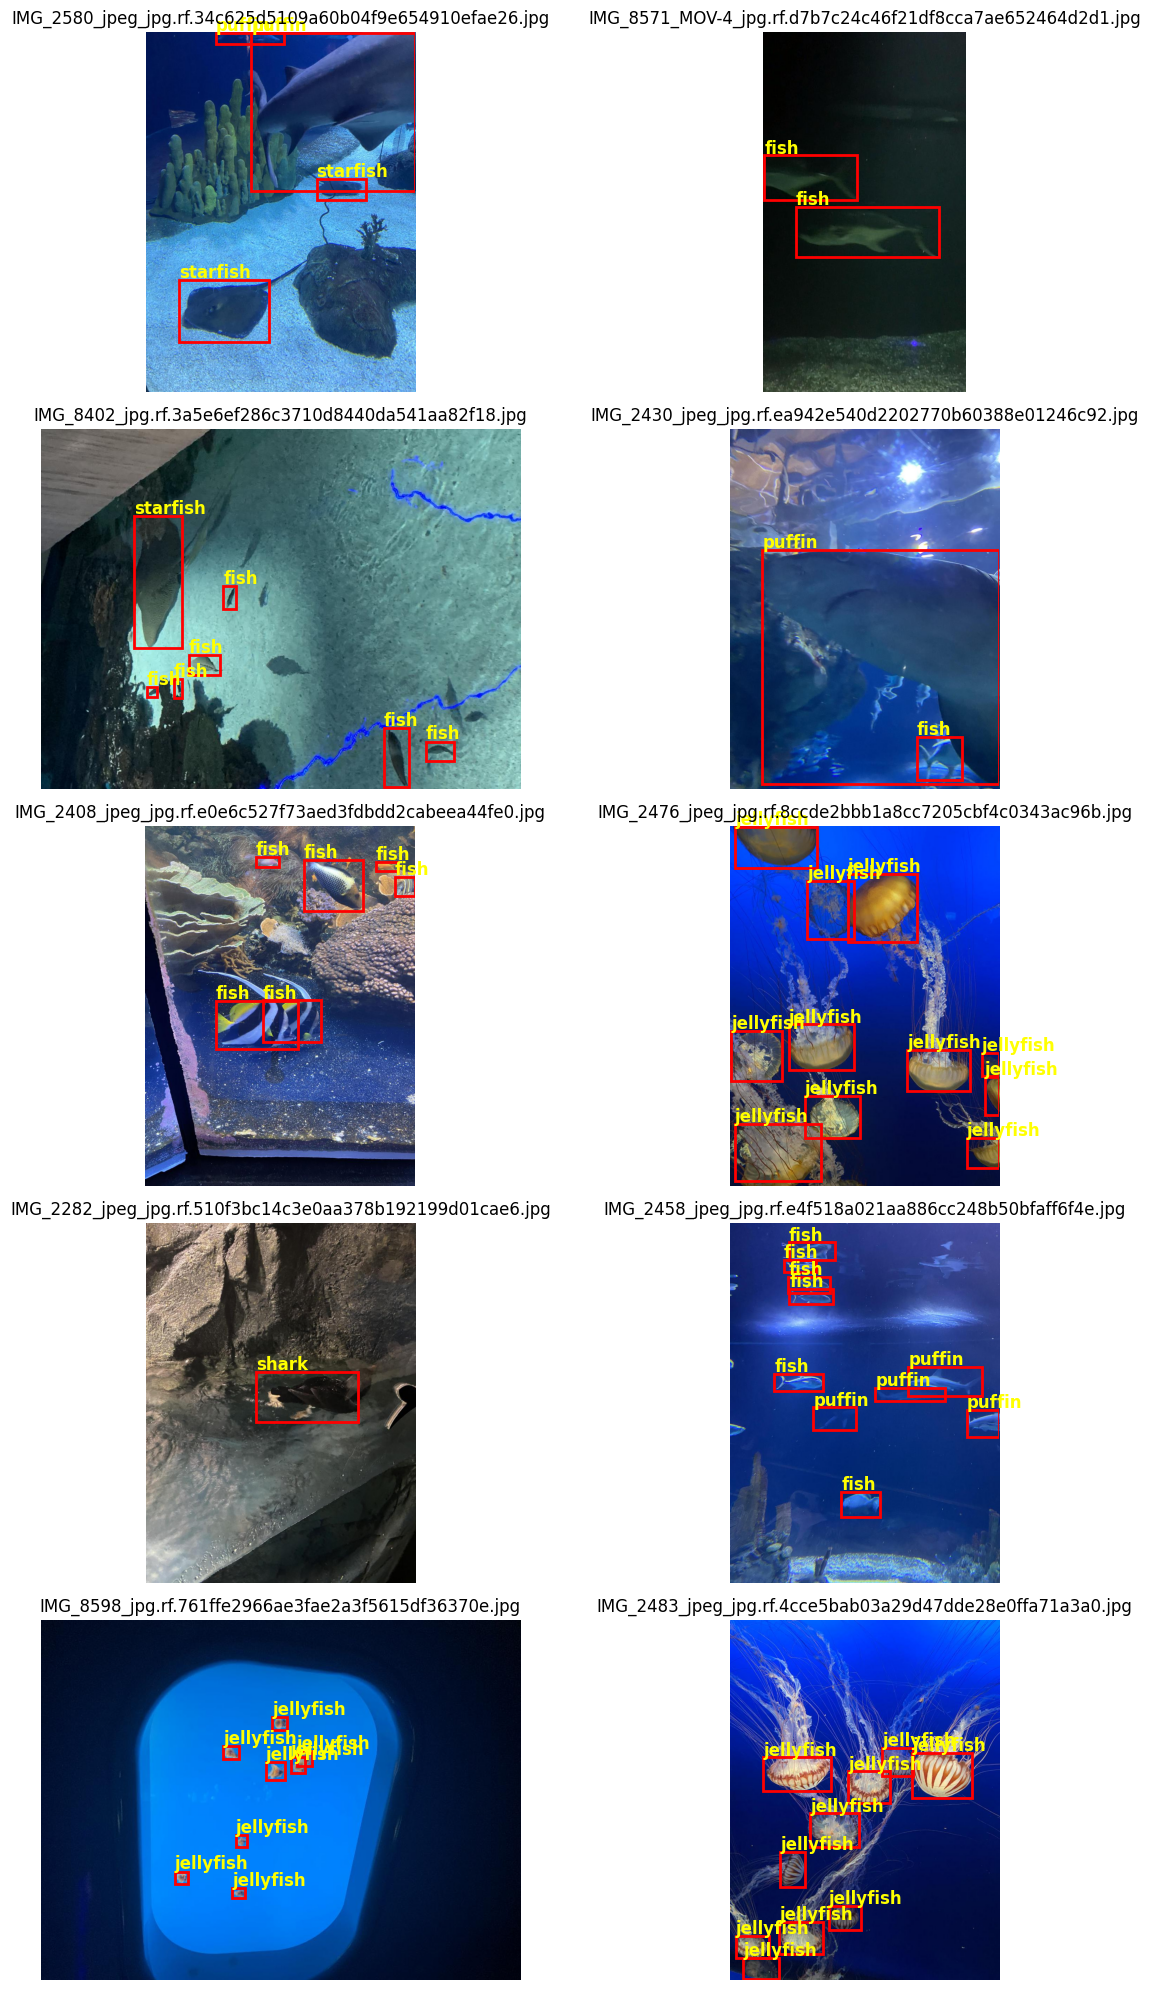

In [4]:
# Show random images from the data-set with thier Bounding Box
sample_imgs = random.sample(image_files, 10)

plt.figure(figsize=(14, 20))

for i, img_name in enumerate(sample_imgs):
    img_path = os.path.join(IMG_DIR, img_name)
    lbl_path = os.path.join(LBL_DIR, os.path.splitext(img_name)[0] + ".txt")

    img = Image.open(img_path).convert("RGB")
    img_w, img_h = img.size

    plt.subplot(5, 2, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_name)

    if os.path.exists(lbl_path):
        boxes, labels = convert_coords(lbl_path, img_w, img_h)

        for (x1, y1, x2, y2), cls_id in zip(boxes, labels):
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor="red", facecolor="none"
            )
            plt.gca().add_patch(rect)

            cls_name = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else str(cls_id)
            plt.text(x1, y1-5, cls_name, color="yellow", fontsize=12, weight="bold")

plt.tight_layout()
plt.show()

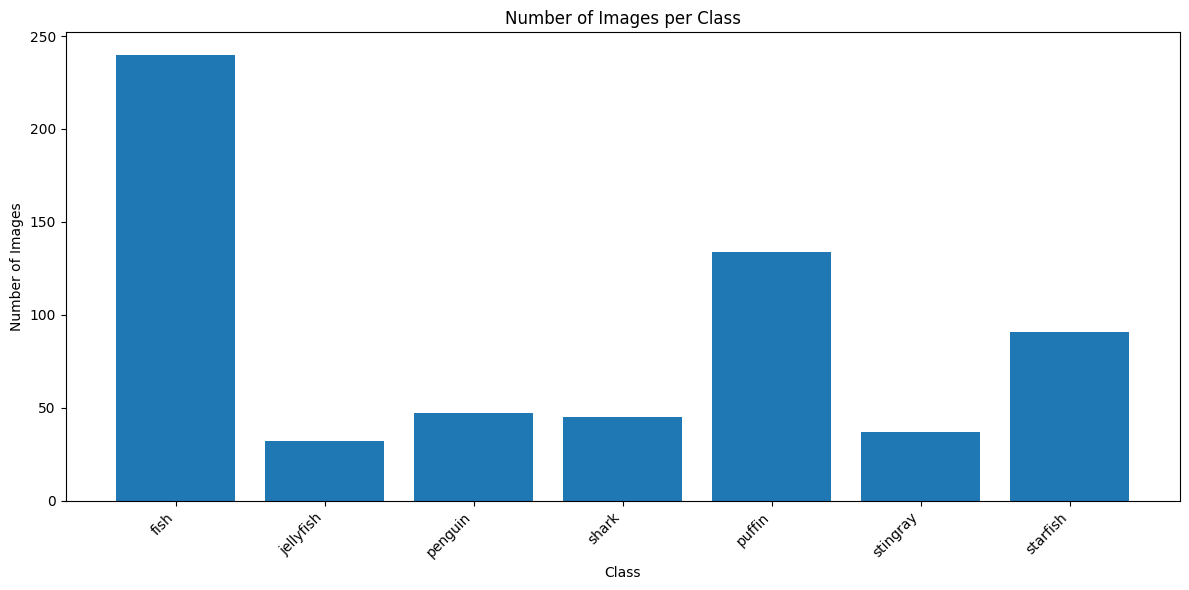

In [5]:
# Number of images in each class( an image can belong to more than one class)
images_per_class = defaultdict(set)

for img_name in os.listdir(IMG_DIR):
    if not img_name.endswith((".jpg",".png",".jpeg")):
        continue

    label_path = os.path.join(LBL_DIR, os.path.splitext(img_name)[0] + ".txt")
    if not os.path.exists(label_path):
        continue

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        cls_id = int(line.split()[0])
        images_per_class[cls_id].add(img_name)

cls_ids = sorted(images_per_class.keys())
counts = [len(images_per_class[c]) for c in cls_ids]
names = [CLASS_NAMES[c] for c in cls_ids]

plt.figure(figsize=(12, 6))
plt.bar(names, counts)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Images")
plt.xlabel("Class")
plt.title("Number of Images per Class")
plt.tight_layout()
plt.show()


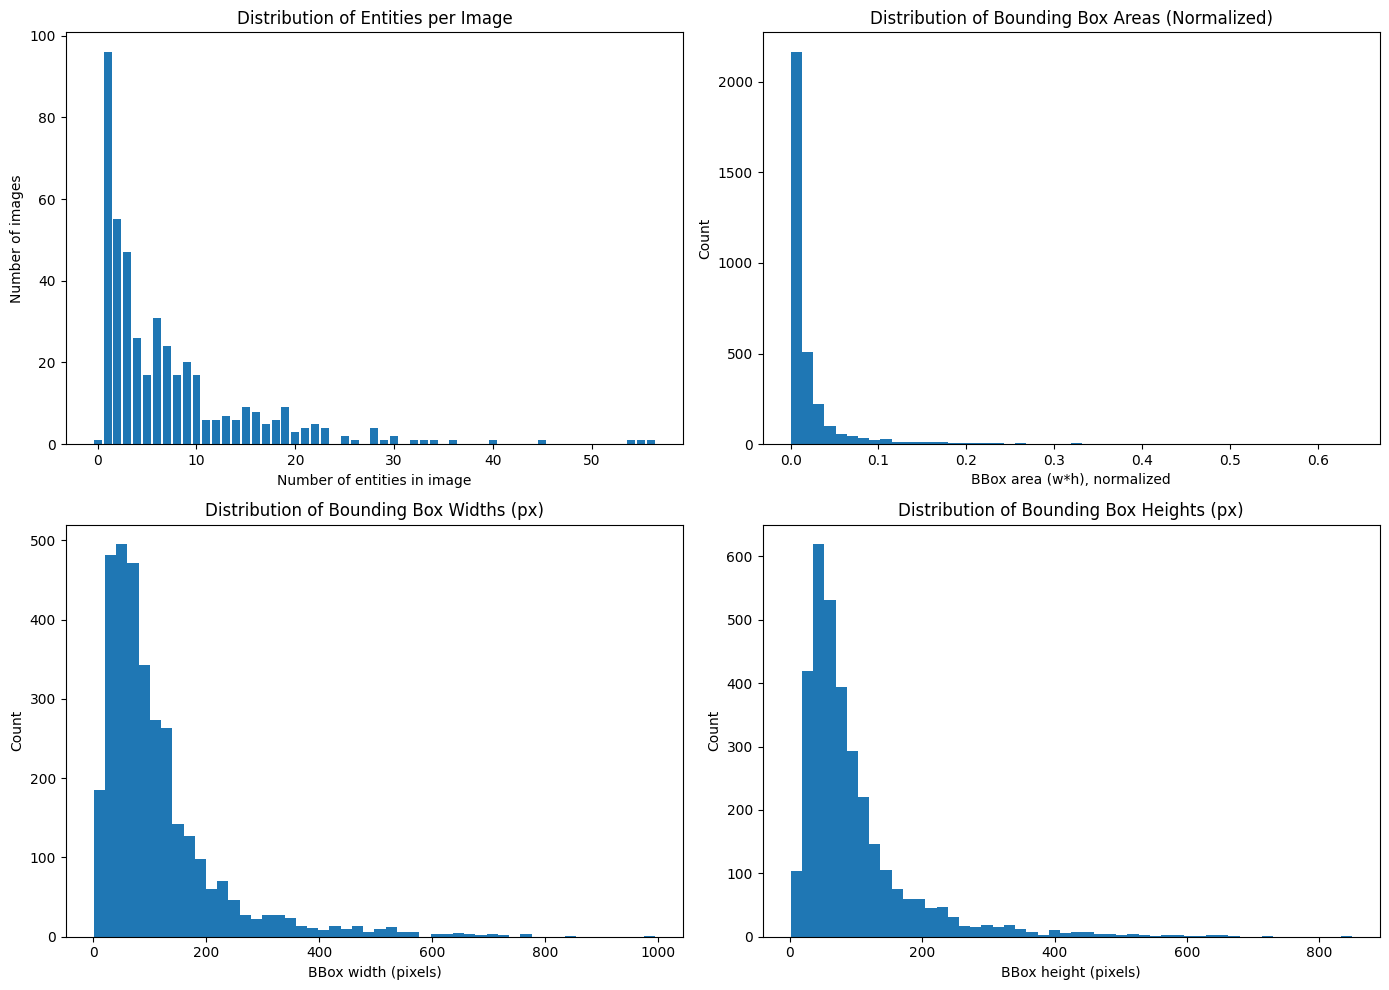

In [6]:
# EDA
entities_per_image = []
box_area_propor = []
box_w_px = []
box_h_px = []

for img_name in image_files:
    img_path = os.path.join(IMG_DIR, img_name)
    if not os.path.exists(img_path):
        continue

    lbl_path = os.path.join(LBL_DIR, os.path.splitext(img_name)[0] + ".txt")
    if not os.path.exists(lbl_path):
        continue

    out = read_label(lbl_path)
    entities_per_image.append(len(out))

    with Image.open(img_path) as im:
        img_w, img_h =  im.size

    for (cls_id, cx, cy, w, h) in out:
        box_area_propor.append(w * h)
        box_w_px.append(w * img_w)
        box_h_px.append(h * img_h)


plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
freq = Counter(entities_per_image)
plt.bar(sorted(freq.keys()), [freq[k] for k in sorted(freq.keys())])
plt.xlabel("Number of entities in image")
plt.ylabel("Number of images")
plt.title("Distribution of Entities per Image")

plt.subplot(2, 2, 2)
plt.hist(box_area_propor, bins=50)
plt.xlabel("BBox area (w*h), normalized")
plt.ylabel("Count")
plt.title("Distribution of Bounding Box Areas (Normalized)")

plt.subplot(2, 2, 3)
plt.hist(box_w_px, bins=50)
plt.xlabel("BBox width (pixels)")
plt.ylabel("Count")
plt.title("Distribution of Bounding Box Widths (px)")

plt.subplot(2, 2, 4)
plt.hist(box_h_px, bins=50)
plt.xlabel("BBox height (pixels)")
plt.ylabel("Count")
plt.title("Distribution of Bounding Box Heights (px)")

plt.tight_layout()
plt.show()


| Augmentation     | Why                         | Effect                         | BBox update                        |
|-----------------|-----------------------------|--------------------------------|-----------------------------------|
| Horizontal Flip  | Increase left-right variance | Mirror image horizontally      | x1_new = W - x2, x2_new = W - x1 |
| Vertical Flip    | Increase up-down variance    | Mirror image vertically        | y1_new = H - y2, y2_new = H - y1 |
| Rotation         | Handle angled objects        |
| Brightness/Contrast | Simulate lighting variation | Change brightness/contrast   | No change                         |
| Gaussian Blur    | Simulate motion/fog          | Blur image                      | No change                         |
| Gaussian Noise   | Simulate sensor noise        | Add random noise               | No change                         |

## Mosaic Augmentation

**Idea:**  
combines 4 images into a single larger image by splitting the canvas into quadrants and placing one image in each.

**Advantages:**  
- Increases the number of objects per image, helping models learn context and detect small objects.  
- Improves generalization by mixing different backgrounds and object arrangements.  
- Makes better use of limited datasets.

**Disadvantages:**  
- Can create unrealistic scenes if objects from different images clash.  
- Requires careful adjustment of bounding boxes.  
- Slightly more complex to implement than basic augmentations.

**Applications:**  
- Object detection tasks, especially when datasets are small.  
- Scenarios with sparse objects to enrich training data.



In [6]:
# Preprocessing
def compute_mean_std(image_files):
    mean = np.zeros(3)
    std = np.zeros(3)
    total_pixels = 0

    arrays = []

    for fname in image_files:
        img = Image.open(os.path.join(IMG_DIR, fname)).convert("RGB")
        arr = np.array(img).astype(np.float32) / 255.0
        arrays.append(arr)

        total_pixels += arr.shape[0] * arr.shape[1]
        mean += arr.sum(axis=(0, 1))

    mean /= total_pixels

    for arr in arrays:
        std += ((arr - mean) ** 2).sum(axis=(0, 1))

    std = np.sqrt(std / total_pixels)

    return mean, std


MEAN, STD = compute_mean_std(image_files)
print("Mean: ", MEAN)
print("Std: ", STD)

def gray_white_balance(img_rgb: Image.Image) -> Image.Image:
    arr = np.asarray(img_rgb).astype(np.float32)
    r_mean = arr[:, :, 0].mean()
    g_mean = arr[:, :, 1].mean()
    b_mean = arr[:, :, 2].mean()
    gray = (r_mean + g_mean + b_mean) / 3.0

    arr[:, :, 0] *= gray / (r_mean + 1e-6)
    arr[:, :, 1] *= gray / (g_mean + 1e-6)
    arr[:, :, 2] *= gray / (b_mean + 1e-6)

    arr = np.clip(arr, 0, 255).astype(np.uint8)
    return Image.fromarray(arr, mode="RGB")

def mosaic_augmentation(image_files, IMG_DIR, LBL_DIR, target_size=(640, 640)):

    assert len(image_files) >= 4

    chosen = random.sample(image_files, 4)
    mosaic_boxes = []
    mosaic_labels = []
    canvas = Image.new("RGB", target_size, (114, 114, 114))

    w_half, h_half = target_size[0] // 2, target_size[1] // 2
    positions = [(0, 0), (w_half, 0), (0, h_half), (w_half, h_half)]

    for i, fname in enumerate(chosen):
        img_path = os.path.join(IMG_DIR, fname)
        lbl_path = os.path.join(LBL_DIR, os.path.splitext(fname)[0] + ".txt")

        img = Image.open(img_path).convert("RGB")
        orig_w, orig_h = img.size

        boxes, labels = [], []
        if os.path.exists(lbl_path):
            boxes, labels = convert_coords(lbl_path, orig_w, orig_h)

        scale_x = w_half / orig_w
        scale_y = h_half / orig_h
        img = img.resize((w_half, h_half), resample=Image.Resampling.BILINEAR)

        # Scale boxes
        boxes_scaled = [
            [x1 * scale_x, y1 * scale_y, x2 * scale_x, y2 * scale_y]
            for x1, y1, x2, y2 in boxes
        ]

        # Paste on canvas
        x_offset, y_offset = positions[i]
        canvas.paste(img, (x_offset, y_offset))

        # Shift boxes into mosaic coordinates
        for (x1, y1, x2, y2), lab in zip(boxes_scaled, labels):
            x1s = x1 + x_offset
            y1s = y1 + y_offset
            x2s = x2 + x_offset
            y2s = y2 + y_offset

            x1s = max(0, min(target_size[0], x1s))
            x2s = max(0, min(target_size[0], x2s))
            y1s = max(0, min(target_size[1], y1s))
            y2s = max(0, min(target_size[1], y2s))

            if x2s <= x1s or y2s <= y1s:
                continue

            mosaic_boxes.append([x1s, y1s, x2s, y2s])
            mosaic_labels.append(lab)

    return canvas, mosaic_boxes, mosaic_labels


def augment_image(img: Image.Image, boxes: list,labels: list,image_files = None):
    # Mosaic augmentation

    if image_files is not None and random.random() < 0.3 and len(image_files) >= 4:
        mosaic_img, mosaic_boxes, mosaic_labels = mosaic_augmentation(image_files, IMG_DIR, LBL_DIR, target_size=(640,640))
        img = mosaic_img
        boxes = mosaic_boxes
        labels = mosaic_labels


    img_arr = np.array(img)
    H, W = img_arr.shape[:2]

    # Horizontal flip
    if random.random() < 0.4:
        img_arr = img_arr[:, ::-1, :]
        # Update boxes: x' = W - x
        new_boxes = []
        for x1, y1, x2, y2 in boxes:
            x1_new = W - x2
            x2_new = W - x1
            new_boxes.append([x1_new, y1, x2_new, y2])
        boxes = new_boxes
    # Vertical flip
    if random.random() < 0.4:
        img_arr = img_arr[::-1, :, :]
        # Update boxes: y' = H - y
        new_boxes = []
        for x1, y1, x2, y2 in boxes:
            y1_new = H - y2
            y2_new = H - y1
            new_boxes.append([x1, y1_new, x2, y2_new])
        boxes = new_boxes

    # Random brightness/contrast
    if random.random() < 0.2:
        alpha = random.uniform(0.8, 1.2)  # contrast
        beta = random.randint(-20, 20)    # brightness
        img_arr = alpha * img_arr + beta
        img_arr = np.clip(img_arr, 0, 255).astype(np.uint8)

    # Gaussian blur
    if random.random() < 0.2:
        k = random.choice([3, 5])
        img_arr = cv2.GaussianBlur(img_arr, (k, k), 0)

    # Gaussian noise
    if random.random() < 0.2:
        noise = np.random.normal(0, 5, img_arr.shape)
        img_arr = img_arr.astype(np.float32) + noise
        img_arr = np.clip(img_arr, 0, 255).astype(np.uint8)

    return Image.fromarray(img_arr), boxes,labels


def processing(image_files, target_size=(640, 640)):
    images = []
    names = []
    labels = []
    boxes = []

    mean = np.array(MEAN, dtype=np.float32)
    std = np.array(STD, dtype=np.float32)

    for fname in tqdm(image_files, desc="Loading + preprocessing"):
        path = os.path.join(IMG_DIR, fname)

        try:
            # Skip corrupt images
            with Image.open(path) as im:
                im.verify()
            img = Image.open(path).convert("RGB")
            lbl_path = os.path.join(LBL_DIR, os.path.splitext(fname)[0] + ".txt")
            orig_w, orig_h = img.size
            boxe, label = convert_coords(lbl_path, orig_w, orig_h) if os.path.exists(lbl_path) else ([], [])
            #augmentation
            img, boxe, label = augment_image(img, boxe,label,image_files)
            # Color changing
            img = gray_white_balance(img)
            # Padding
            img.thumbnail(target_size, resample=Image.Resampling.BILINEAR)
            canvas = Image.new("RGB", target_size, (114, 114, 114))
            x = (target_size[0] - img.size[0]) // 2
            y = (target_size[1] - img.size[1]) // 2
            canvas.paste(img, (x, y))
            img = canvas
            # Normalizing
            arr = np.asarray(img)
            arr = arr.astype(np.float32) / 255.0
            arr = (arr - mean) / std

            images.append(arr)
            names.append(fname)
            boxes.append(boxe)
            labels.append(label)

        except Exception as e:
            print(f"Error processing {fname}: {e}")
            continue

    return np.stack(images, axis=0) if images else np.empty((0, target_size[1], target_size[0], 3)), names, boxes, labels





Mean:  [0.29001335 0.35291484 0.43819457]
Std:  [0.23016101 0.22007963 0.23189242]


In [ ]:
def show_augmentation_examples(image_files, n_samples=5):
    plt.figure(figsize=(20, 8))

    for i, fname in enumerate(random.sample(image_files, n_samples)):
        img_path = os.path.join(IMG_DIR, fname)
        lbl_path = os.path.join(LBL_DIR, os.path.splitext(fname)[0] + ".txt")

        img_orig = Image.open(img_path).convert("RGB")
        orig_w, orig_h = img_orig.size
        boxes_orig, labels_orig = convert_coords(lbl_path, orig_w, orig_h) if os.path.exists(lbl_path) else ([], [])

        img_aug, boxes_aug,labels_aug = augment_image(img_orig, boxes_orig,labels_orig)

        plt.subplot(2, n_samples, i+1)
        plt.imshow(img_orig)
        for (x1, y1, x2, y2), label in zip(boxes_orig, labels_orig):
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=2, edgecolor="red", facecolor="none")
            plt.gca().add_patch(rect)

            plt.text(x1, y1-5, str(label), color='red', fontsize=8,
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
        plt.title(f"Original\n{len(boxes_orig)} objects", fontsize=10)
        plt.axis("off")


        plt.subplot(2, n_samples, n_samples+i+1)
        plt.imshow(img_aug)
        for (x1, y1, x2, y2), label in zip(boxes_aug, labels_aug):
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=2, edgecolor="lime", facecolor="none")
            plt.gca().add_patch(rect)

            plt.text(x1, y1-5, str(label), color='lime', fontsize=8,
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
        plt.title(f"Augmented\n{len(boxes_aug)} objects", fontsize=10)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_augmentation_examples(image_files)


In [ ]:
# Generate and visualize 3 mosaic examples
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

for i in range(3):
    mosaic_img, mosaic_boxes, mosaic_labels = mosaic_augmentation(
        image_files, IMG_DIR, LBL_DIR, target_size=(640, 640)
    )

    axs[i].imshow(mosaic_img)
    for (x1, y1, x2, y2), cls_id in zip(mosaic_boxes, mosaic_labels):
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                               linewidth=2, edgecolor="lime", facecolor="none")
        axs[i].add_patch(rect)
        cls_name = CLASS_NAMES[cls_id]
        axs[i].text(x1, y1-10, cls_name, color="yellow", fontsize=12, weight="bold")

    axs[i].set_title(f"Mosaic Example {i+1}")
    axs[i].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# Showing images before and after preprocessing
sample_files = random.sample(image_files, min(5, len(image_files)))

processed_images, processed_names,_,_ = processing(sample_files,target_size=(640, 640))
processed_dict = dict(zip(processed_names, processed_images))

plt.figure(figsize=(12, 20))

for i, fname in enumerate(sample_files):
    original = Image.open(os.path.join(IMG_DIR, fname)).convert("RGB")
    original = np.array(original)

    processed = processed_dict[fname]

    plt.subplot(10, 2, 2*i + 1)
    plt.imshow(original)
    plt.title("Before")
    plt.axis("off")

    plt.subplot(10, 2, 2*i + 2)
    plt.imshow(processed.astype(np.uint8))
    plt.title("After")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [7]:
class DetectionDataset(Dataset):
    def __init__(self, image_files):
        self.images, self.names,self.boxes,self.labels = processing(image_files)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        boxes = self.boxes[idx]
        labels = self.labels[idx]

        return img, boxes, labels


dataset = DetectionDataset(image_files)


Loading + preprocessing:   0%|          | 0/448 [00:00<?, ?it/s]/tmp/ipython-input-3091070650.py:43: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="RGB")
Loading + preprocessing: 100%|██████████| 448/448 [00:40<00:00, 11.20it/s]


In [9]:
def detection_collate_fn(batch):

    images = []
    all_boxes = []
    all_labels = []

    for img, boxes, labels in batch:

        # Convert image to tensor (C,H,W)
        img_tensor = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)
        images.append(img_tensor)

        all_boxes.append(boxes)
        all_labels.append(labels)

    # Stack images
    images = torch.stack(images)

    batch_size = len(batch)
    max_objects = max(len(b) for b in all_boxes)

    padded_boxes = torch.zeros((batch_size, max_objects, 4), dtype=torch.float32)
    padded_labels = torch.zeros((batch_size, max_objects), dtype=torch.long)
    mask = torch.zeros((batch_size, max_objects), dtype=torch.bool)

    for i in range(batch_size):
        num_objs = len(all_boxes[i])

        if num_objs > 0:
            padded_boxes[i, :num_objs] = torch.tensor(all_boxes[i], dtype=torch.float32)
            padded_labels[i, :num_objs] = torch.tensor(all_labels[i], dtype=torch.long)
            mask[i, :num_objs] = True

    return images, padded_boxes, padded_labels, mask


from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=detection_collate_fn
)

images, boxes, labels, mask = next(iter(train_loader))

print("Images shape:", images.shape)
print("Boxes shape:", boxes.shape)
print("Labels shape:", labels.shape)
print("Mask shape:", mask.shape)

print("\nExample mask:")
print(mask)


Images shape: torch.Size([4, 3, 640, 640])
Boxes shape: torch.Size([4, 26, 4])
Labels shape: torch.Size([4, 26])
Mask shape: torch.Size([4, 26])

Example mask:
tensor([[ True, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False],
        [ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True,  True,  True,  True,  True, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False],
        [ True, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False]])